In [ ]:
# Клонируем репозиторий
!git clone https://github.com/aldarovav/TS_project.git


In [ ]:

# Устанавливаем зависимости строго из requirements.txt
!pip install -r requirements.txt --quiet

In [8]:
%cd TS_project

/kaggle/working/TS_project


In [10]:
# %% [markdown]
# # Анализ влияния нормализации на качество прогнозирования
# 
# В этом ноутбуке мы загружаем результаты эксперимента и строим графики.

# %%
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess
import sys
import darts
import torch 


In [4]:
from darts.models import NBEATSModel
from sktime.forecasting.theta import ThetaForecaster

> **Важно**: Этот ноутбук автоматически запустит эксперимент, если файл с результатами (`smape_results.csv`) отсутствует. Эксперимент может занять продолжительное время (до нескольких десятков минут). При повторных запусках эксперимент не будет выполняться заново (если файл уже существует). Чтобы принудительно перезапустить эксперимент, удалите файл `results/smape_results.csv` или выполните скрипт `run_experiment.py` вручную.

In [17]:
# Параметры эксперимента
N_SERIES = 200          # количество временных рядов (для быстрого теста можно 10-20)
EPOCHS = 10            # количество эпох для нейросети (для скорости уменьшите)
DATA_GROUP = 'Monthly' # 'Monthly', 'Quarterly', 'Yearly' и т.д.
HORIZON = 18           # горизонт прогноза (для Monthly обычно 18)
DEFAULT_DEVICE = 'gpu' if torch.cuda.is_available() else 'cpu'
DEVICE = DEFAULT_DEVICE   # по умолчанию – авто

In [18]:
# Определяем корневую папку проекта (там, где лежит run_experiment.py)
# Если ноутбук находится в results/, поднимаемся на уровень выше
# Определяем корневую папку проекта (там, где лежит run_experiment.py)
notebook_dir = os.getcwd()
if notebook_dir.endswith('results'):
    project_root = os.path.dirname(notebook_dir)
else:
    project_root = notebook_dir

# Проверяем наличие run_experiment.py
run_script = os.path.join(project_root, 'run_experiment.py')
if not os.path.exists(run_script):
    raise FileNotFoundError(f"Не найден run_experiment.py по пути {run_script}")

# Имя файла результатов
results_filename = f"smape_results_{DATA_GROUP}_h{HORIZON}_n{N_SERIES}_e{EPOCHS}_{DEVICE}.csv"
results_file = os.path.join('results', results_filename)

if not os.path.exists(results_file):
    print(f"Файл {results_file} не найден. Запускаем эксперимент с параметрами:")
    print(f"  n_series={N_SERIES}, epochs={EPOCHS}, device={DEVICE}, data_group={DATA_GROUP}, horizon={HORIZON}")
    
    # Сохраняем текущую директорию (results/) чтобы потом вернуться
    original_dir = os.getcwd()
    # Переходим в корень проекта
    os.chdir(project_root)
    print(f"Перешли в {os.getcwd()}, запускаем:")
    
    # Формируем команду для ! (shell)
    cmd = f"python run_experiment.py --n_series={N_SERIES} --epochs={EPOCHS} --device={DEVICE} --data_group={DATA_GROUP} --horizon={HORIZON}"
    
    # Выполняем команду через ! (вывод будет в реальном времени)
    !{cmd}
    
    # Возвращаемся обратно в results/
    os.chdir(original_dir)
    print(f"Вернулись в {os.getcwd()}")
    
    # Проверяем, создался ли файл
    if os.path.exists(results_file):
        print("Эксперимент успешно завершён.")
    else:
        print("ВНИМАНИЕ: файл результатов не найден после выполнения. Проверьте вывод выше на наличие ошибок.")
else:
    print(f"Файл {results_file} уже существует. Эксперимент не запускается.")

Файл results/smape_results_Monthly_h18_n200_e10_gpu.csv не найден. Запускаем эксперимент с параметрами:
  n_series=200, epochs=10, device=gpu, data_group=Monthly, horizon=18
Перешли в /kaggle/working/TS_project, запускаем:
Параметры эксперимента: data_group=Monthly, horizon=18, n_series=200, epochs=10, device=gpu
Загружено 200 рядов.
Используется 200 рядов после проверки длины.

=== Scaling: None ===
  Baseline: naive
  Baseline: seasonal_naive                                                      
  Baseline: theta                                                               
  Baseline: ets                                                                 
  Global: catboost                                                              
🚀 Starting CatBoost training on GPU...
✅ CatBoost training completed.
  Global: nbeats
🚀 Starting N-BEATS training on GPU with batch_size=128, epochs=10...
INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 173000 samples.
INFO:

In [ ]:
# Определяем корневую папку проекта (там, где лежит run_experiment.py)
# Если ноутбук находится в results/, поднимаемся на уровень выше
# Определяем корневую папку проекта (там, где лежит run_experiment.py)
notebook_dir = os.getcwd()
if notebook_dir.endswith('results'):
    project_root = os.path.dirname(notebook_dir)
else:
    project_root = notebook_dir

# Проверяем наличие run_experiment.py
run_script = os.path.join(project_root, 'run_experiment.py')
if not os.path.exists(run_script):
    raise FileNotFoundError(f"Не найден run_experiment.py по пути {run_script}")

# Имя файла результатов
results_filename = f"smape_results_{DATA_GROUP}_h{HORIZON}_n{N_SERIES}_e{EPOCHS}_{DEVICE}.csv"
results_file = os.path.join('results', results_filename)

if not os.path.exists(results_file):
    print(f"Файл {results_file} не найден. Запускаем эксперимент с параметрами:")
    print(f"  n_series={N_SERIES}, epochs={EPOCHS}, device={DEVICE}, data_group={DATA_GROUP}, horizon={HORIZON}")
    
    # Сохраняем текущую директорию (results/) чтобы потом вернуться
    original_dir = os.getcwd()
    # Переходим в корень проекта
    os.chdir(project_root)
    print(f"Перешли в {os.getcwd()}, запускаем:")
    
    # Формируем команду для ! (shell)
    cmd = f"python run_experiment.py --n_series={N_SERIES} --epochs={EPOCHS} --device={DEVICE} --data_group={DATA_GROUP} --horizon={HORIZON}"
    
    # Выполняем команду через ! (вывод будет в реальном времени)
    !{cmd}
    
    # Возвращаемся обратно в results/
    os.chdir(original_dir)
    print(f"Вернулись в {os.getcwd()}")
    
    # Проверяем, создался ли файл
    if os.path.exists(results_file):
        print("Эксперимент успешно завершён.")
    else:
        print("ВНИМАНИЕ: файл результатов не найден после выполнения. Проверьте вывод выше на наличие ошибок.")
else:
    print(f"Файл {results_file} уже существует. Эксперимент не запускается.")

Файл results/smape_results_Monthly_h18_n200_e10_gpu.csv не найден. Запускаем эксперимент с параметрами:
  n_series=200, epochs=10, device=gpu, data_group=Monthly, horizon=18
Перешли в /kaggle/working/TS_project, запускаем:
Параметры эксперимента: data_group=Monthly, horizon=18, n_series=200, epochs=10, device=gpu
Загружено 200 рядов.
Используется 200 рядов после проверки длины.

=== Scaling: None ===
  Baseline: naive
  Baseline: seasonal_naive                                                      
  Baseline: theta                                                               
  Baseline: ets                                                                 
  Global: catboost                                                              
🚀 Starting CatBoost training on GPU...
✅ CatBoost training completed.
  Global: nbeats
🚀 Starting N-BEATS training on GPU with batch_size=128, epochs=10...
INFO:darts.models.forecasting.torch_forecasting_model:Train dataset contains 173000 samples.
INFO:

In [19]:
# Загрузка результатов в DataFrame

# Используем только имя файла, без папки results
if os.path.exists(results_file):
    df = pd.read_csv(results_file, index_col=0)
    print("Результаты загружены:")
    display(df)
else:
    print(f"Файл {results_filename} не найден в текущей директории: {os.getcwd()}")

Результаты загружены:


,Unnamed: 1,standard,robust,quantile
naive,8.922356,8.922356,8.922356,8.922356
seasonal_naive,10.577445,10.577445,10.577445,10.577445
theta,6.737191,6.737193,6.737193,7.228848
ets,7.020748,6.759284,6.766841,7.565123
catboost,8.095492,7.885449,7.350873,10.000275
nbeats,7.270208,7.684221,7.153934,9.690424


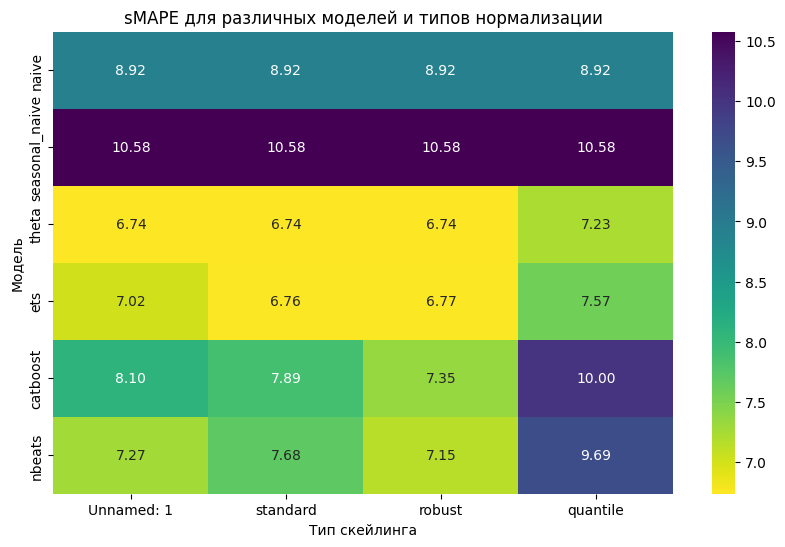

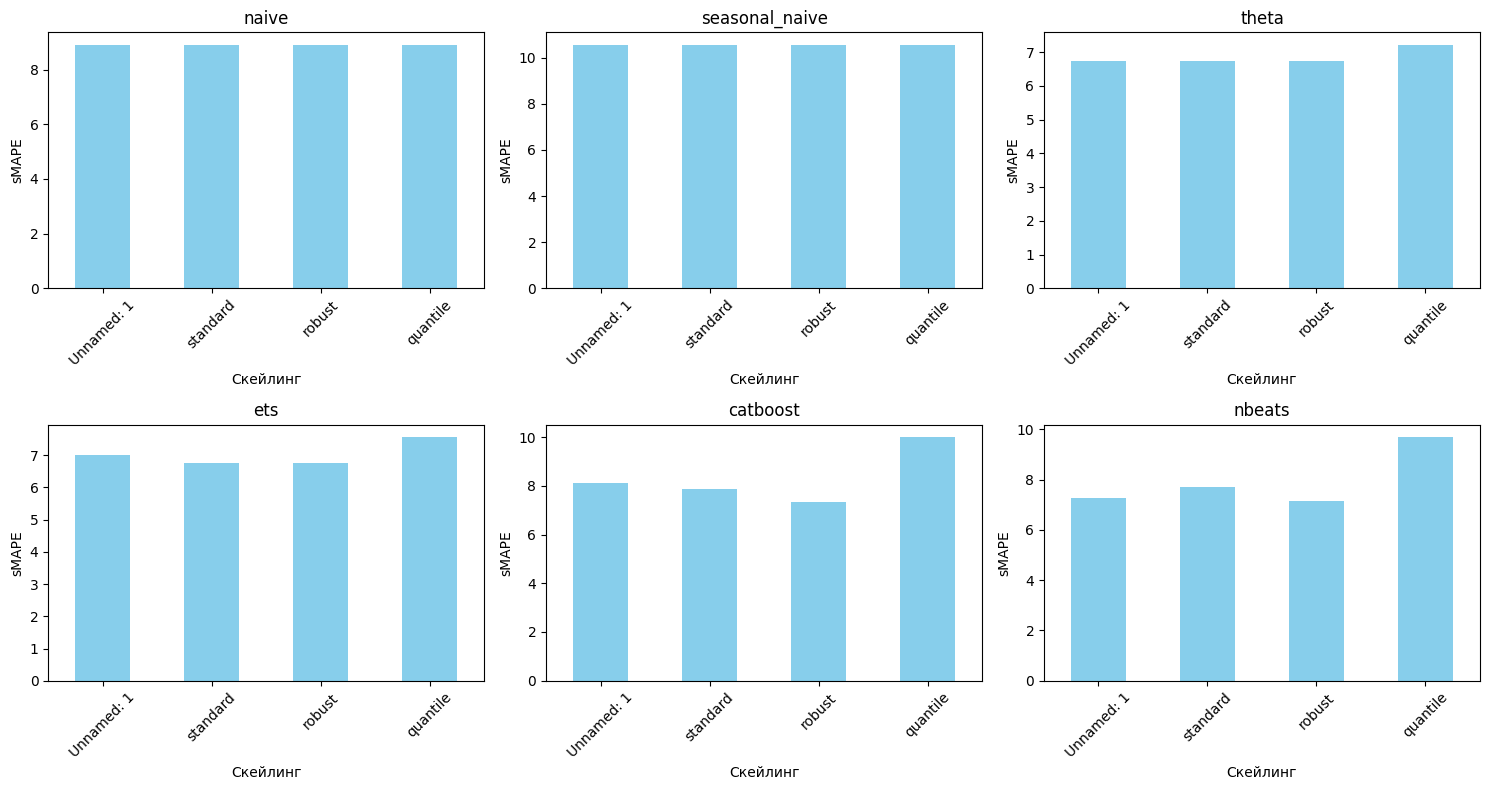

<Figure size 800x500 with 0 Axes>

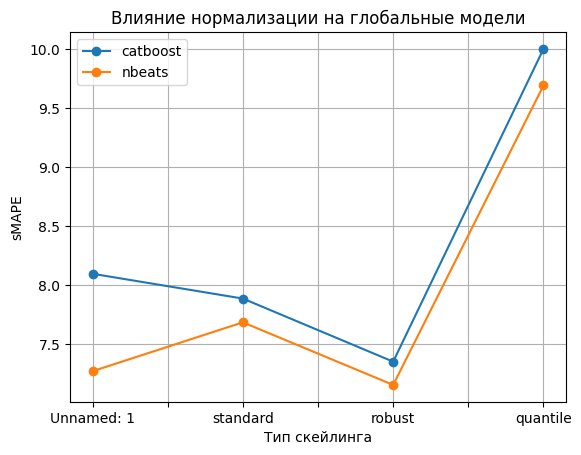

In [20]:

# %%
# Тепловая карта
plt.figure(figsize=(10, 6))
sns.heatmap(df, annot=True, fmt='.2f', cmap='viridis_r')
plt.title('sMAPE для различных моделей и типов нормализации')
plt.xlabel('Тип скейлинга')
plt.ylabel('Модель')
plt.show()

# %%
# Сравнение для каждой модели отдельно
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, model in enumerate(df.index):
    ax = axes[i]
    df.loc[model].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(model)
    ax.set_ylabel('sMAPE')
    ax.set_xlabel('Скейлинг')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# %%
# Сравнение для глобальных моделей
plt.figure(figsize=(8, 5))
df.loc[['catboost', 'nbeats']].T.plot(marker='o')
plt.title('Влияние нормализации на глобальные модели')
plt.ylabel('sMAPE')
plt.xlabel('Тип скейлинга')
plt.grid(True)
plt.show()

# %%
# Выводы (заполните на основе полученных цифр)
# Например:
# - Для бейзлайнов нормализация практически не влияет (или влияет слабо).
# - CatBoost показывает улучшение при RobustScaler.
# - PatchTST сильно выигрывает от любой нормализации, особенно StandardScaler.

In [ ]:
df